# Exploratory Data Analysis and Reproducible Data Preparation

This notebook builds the corrected article dataset while retaining the submitted one-off midpoint repair. Run it before `results.ipynb`. Daily external series are aligned using past-only filling, Yang-Zhang warm-up rows are dropped rather than backfilled, and the frozen `daily_data/` files remain the reproducibility inputs. The submitted dissertation PDF and `methodology-preservation.txt` document the archived methodology.


**Disclaimer**: A considerable portion of the coding was supported by coding assistants. However, all modeling decisions — including architecture, metric design, and evaluation criteria — were researcher-led. The role of such tools was to accelerate implementation, not to substitute conceptual responsibility.

In [1]:
import sys,os
import yfinance as yf
import pandas as pd
from datetime import datetime
from pathlib import Path
import numpy as np
import ta 
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from src.features import (
    add_dissertation_period_flags,
    add_grouped_log_returns,
    add_technical_indicators,
    add_ticker_one_hot as build_ohe,
    add_yang_zhang_volatility_causal as add_yz_volatility,
    impute_midpoint,
    parse_mixed_dates as parse_dates,
)
from src.metrics import (
    bmr as submitted_bmr,
    bmr_tolerant as submitted_bmr_tolerant,
    bmr_z as submitted_bmr_z,
    pooled_bmr_z as submitted_pooled_bmr_z,
    r_squared as submitted_r_squared,
    rmse as submitted_rmse,
    robust_bmr_z_threshold as submitted_robust_bmr_z_threshold,
)
from src.splits import fixed_dissertation_split
sns.set_context("notebook")

# All regenerated files are kept beneath one project-level output directory.
OUTPUT_ROOT = Path("outputs") / "paper"
EDA_OUTPUT_DIR = OUTPUT_ROOT / "eda"
DATA_OUTPUT_DIR = OUTPUT_ROOT / "data"
EDA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


## 1. Inputs and Data Loading

The reproducible workflow uses the frozen daily CSV files. The live-download cell is retained for provenance but remains disabled.


### 1.1 Optional Yahoo Finance Refresh — Disabled


In [2]:
# the data on Yahoo finance on two tickers has changed, therefore I use earlied downloaded data to ensure reproducibility before I do any changes to the models

'''# Define tickers and company names
tickers = {
    "Bluefield Solar Income Fund": "BSIF.L",
    "Greencoat UK Wind": "UKW.L",
    "Tullow Oil plc": "TLW.L",
    "Hunting plc": "HTG.L",
    "SSE plc": "SSE.L",
    "FTSE 100": "^FTSE",
    "FTSE 250": "^FTMC",
    "FTSE All-Share": "^FTAS"
}



# Set time range
start_date = "2015-01-01"
end_date = "2025-07-19"
#datetime.today().strftime("%Y-%m-%d")

# Create folder for CSVs (optional)
import os
os.makedirs("daily_data", exist_ok=True)

# Download and save
for name, symbol in tickers.items():
    df = yf.download(symbol, start=start_date, end=end_date, interval="1d")
    filename = f"daily_data/{symbol.replace('.L','')}_daily.csv"
    df.to_csv(filename)
    
'''


'# Define tickers and company names\ntickers = {\n    "Bluefield Solar Income Fund": "BSIF.L",\n    "Greencoat UK Wind": "UKW.L",\n    "Tullow Oil plc": "TLW.L",\n    "Hunting plc": "HTG.L",\n    "SSE plc": "SSE.L",\n    "FTSE 100": "^FTSE",\n    "FTSE 250": "^FTMC",\n    "FTSE All-Share": "^FTAS"\n}\n\n\n\n# Set time range\nstart_date = "2015-01-01"\nend_date = "2025-07-19"\n#datetime.today().strftime("%Y-%m-%d")\n\n# Create folder for CSVs (optional)\nimport os\nos.makedirs("daily_data", exist_ok=True)\n\n# Download and save\nfor name, symbol in tickers.items():\n    df = yf.download(symbol, start=start_date, end=end_date, interval="1d")\n    filename = f"daily_data/{symbol.replace(\'.L\',\'\')}_daily.csv"\n    df.to_csv(filename)\n\n'

### 1.2 Load the Frozen Daily Price Files


In [3]:
# Read and combine all CSV files in the folder
folder = "daily_data"
all_data = []

for file in os.listdir(folder):
    if file.endswith(".csv"):
        path = os.path.join(folder, file)
        df = pd.read_csv(path, index_col=0, parse_dates=True, date_format="%d/%m/%Y")
        df.index.name = "Date"
        df["Source"] = file.replace("_daily.csv", "").replace("^", "")
        all_data.append(df)

# Combine all data
combined_df = pd.concat(all_data).sort_index()

# Remove rows with index like "Date" or "Ticker"
combined_df = combined_df[~combined_df.index.isin(["Date", "Ticker"])]

# Validate index as datetime
raw_index = combined_df.index
datetime_index = pd.to_datetime(raw_index, errors="coerce")

# Count and remove invalid datetime rows
invalid_count = datetime_index.isna().sum()
if invalid_count > 0:
    print(f"Removed {invalid_count} rows with invalid datetime index.")
    combined_df = combined_df[datetime_index.notna()]

# Final: assign valid datetime index
combined_df.index = pd.to_datetime(combined_df.index)

# Step 1: Inspect the data before removing anything
print("First few rows of the combined data:")
print(combined_df.head(15))

# Step 2: Check if 'Date' index is valid
raw_index = combined_df.index
datetime_index = pd.to_datetime(raw_index, errors="coerce")

# Show rows with invalid datetime entries
invalid_rows = combined_df[datetime_index.isna()]
print("\nRows with invalid datetime index (if any):")
print(invalid_rows)

# Count invalid rows
invalid_count = datetime_index.isna().sum()
print(f"\nTotal number of rows with invalid datetime index: {invalid_count}")

# Optionally: Print the unique values in the index to see if there are any obvious issues
#print("\nUnique index values (Date part):")
#print(combined_df.index.unique())

First few rows of the combined data:
                         Close                High                 Low  \
Date                                                                     
2015-01-02  110.29319763183594  110.79001383738475  110.17395901341129   
2015-01-02     1596.2255859375  1622.0673451120797  1591.8523408886356   
2015-01-02  102.51530456542969  102.57776688144453  102.13897005841288   
2015-01-02   3524.090087890625     3551.1201171875              3505.0   
2015-01-02     6547.7998046875    6607.89990234375    6510.60009765625   
2015-01-02             16052.0     16103.099609375    15977.7001953125   
2015-01-02   352.5762634277344   359.1323144109831  345.93514975767766   
2015-01-02   522.9330444335938   541.3953752008103   513.9513700062992   
2015-01-05   3462.389892578125    3539.43994140625   3456.239990234375   
2015-01-05     6417.2001953125     6576.7001953125              6404.5   
2015-01-05    15921.7001953125     16141.400390625             15910.5   
2

## 2. Data Quality and Cleaning


### 2.1 Check Panel Completeness and Missing Ticker-Date Rows


In [4]:
# Number of actual rows in the DataFrame
actual_rows = len(combined_df)

# Number of unique tickers
unique_tickers = combined_df['Source'].nunique()

# Number of unique dates (i.e., trading days across the full range)
unique_dates = combined_df.index.nunique()

# Expected: one row per (ticker, date) pair
expected_rows = unique_tickers * unique_dates

print(f"Tickers: {unique_tickers}")
print(f"Unique dates: {unique_dates}")
print(f"Expected rows (complete matrix): {expected_rows}")
print(f"Actual rows: {actual_rows}")
print(f"Missing rows: {expected_rows - actual_rows}")


Tickers: 8
Unique dates: 2664
Expected rows (complete matrix): 21312
Actual rows: 21311
Missing rows: 1


In [5]:
# Generate complete set of (Date, Source) combinations
all_dates = combined_df.index.normalize().unique()
all_tickers = combined_df['Source'].unique()

# Create a DataFrame with all expected combinations
full_grid = pd.DataFrame([(date, ticker) for date in all_dates for ticker in all_tickers],
                         columns=["Date", "Source"])
full_grid["Date"] = pd.to_datetime(full_grid["Date"])

# Merge with existing data to identify missing rows
combined_df_reset = combined_df.reset_index()
merged = full_grid.merge(combined_df_reset, on=["Date", "Source"], how="left", indicator=True)

# Extract missing rows
missing_rows = merged[merged["_merge"] == "left_only"].drop(columns="_merge")
print("Missing (Date, Ticker) combinations:")
print(missing_rows)


Missing (Date, Ticker) combinations:
            Date Source Close High  Low Open Volume
12100 2020-12-22   FTSE   NaN  NaN  NaN  NaN    NaN


### 2.2 Convert Numeric Fields and Repair Submitted Missing Values


In [6]:
df_fix = combined_df.copy()
print("Column data types:")
print(df_fix.dtypes)


Column data types:
Close     object
High      object
Low       object
Open      object
Volume    object
Source    object
dtype: object


In [7]:
# List all columns you want to convert
columns_to_convert = ["Close", "High", "Low", "Open", "Volume"]

# Convert them to numeric (invalid strings will become NaN)
df_fix[columns_to_convert] = df_fix[columns_to_convert].apply(pd.to_numeric, errors="coerce")

# Confirm result
print("\nAfter conversion:")
print(df_fix.dtypes)



After conversion:
Close     float64
High      float64
Low       float64
Open      float64
Volume      int64
Source     object
dtype: object


In [8]:
df_fix = impute_midpoint(df_fix, "2020-12-22", "FTSE")
df_fix.shape

(21312, 6)

In [9]:
df_fix.index.name = "Date"
print("Index structure of df_fix:")
print(df_fix.index.names)
print("Columns in df_fix:")
print(df_fix.columns)

Index structure of df_fix:
['Date']
Columns in df_fix:
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Source'], dtype='object')


In [10]:
# Check that 'Date' is indeed a datetime index
print("Is 'Date' index a timestamp?")
print(pd.api.types.is_datetime64_any_dtype(df_fix.index))

Is 'Date' index a timestamp?
True


In [11]:
#check if there are more missing values
df_fix.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
Source    0
dtype: int64

## 3. Feature Engineering


### 3.1 Bank of England Policy Rate


In [12]:

# 1) Load & tidy BoE as a daily step series indexed by date
boe = (
    pd.read_csv("not_ready_or_daily_data/Bank_Rate_history_BoE_start_from_merge.csv")
      .assign(
          Date=lambda d: pd.to_datetime(d['Date Changed'], format='%d-%b-%y', errors='coerce').dt.normalize(),
          BoE_R=lambda d: pd.to_numeric(d['Rate'].astype(str).str.replace('%','', regex=False).str.strip(), errors='coerce')
      )
      .loc[:, ['Date', 'BoE_R']]
      .dropna()
      .sort_values('Date')
      .drop_duplicates('Date', keep='last')
      .set_index('Date')['BoE_R']
)

# 2) Map rates to df_fix's dates via forward-fill, then fill only the leading values
df_fix_b = df_fix.copy()
idx = df_fix_b.index.normalize()            # safe even if already date-only
rates_on_idx = boe.reindex(idx, method='ffill')
df_fix_b['BoE_R'] = rates_on_idx.fillna(boe.iloc[0]).to_numpy()

#  sanity check around the 2016-08-04 cut:
#print(df_fix_b.loc['2016-08-03':'2016-08-05', ['BoE_R']])


#df_fix_b.head()

### 3.2 CPIH Inflation Rate Aligned to Release Dates


In [13]:
# loads release and CPIH rates columns
rel = pd.read_excel(
    "not_ready_or_daily_data/CPIH_monthly_Oct_2013_to_June_2025.xlsx",
    usecols=["Release", "CPIH_rate"]
).copy()

# Coerce rate
rel["CPIH_rate"] = pd.to_numeric(rel["CPIH_rate"], errors="coerce")

# Parse Release robustly: try normal parsing, then Excel serials for any leftovers
rel["release_date"] = pd.to_datetime(rel["Release"], errors="coerce", dayfirst=True)

mask_nat = rel["release_date"].isna()
if mask_nat.any():
    serial = pd.to_numeric(rel.loc[mask_nat, "Release"], errors="coerce")
    serial_mask = serial.notna()
    if serial_mask.any():
        base = pd.Timestamp("1899-12-30")  # Excel date origin
        rel.loc[serial_mask.index[serial_mask], "release_date"] = base + pd.to_timedelta(serial[serial_mask], unit="D")

# Clean & order
rel = (
    rel.dropna(subset=["release_date", "CPIH_rate"])
       .assign(release_date=lambda d: d["release_date"].dt.normalize())
       .sort_values("release_date")
       .drop_duplicates(subset=["release_date"], keep="last")
       [["release_date", "CPIH_rate"]]
)

# Builds daily stepwise series from the release dates ---
start = rel["release_date"].min()                      # first known release
end   = rel["release_date"].max() + pd.Timedelta(60, "D")  # extend beyond last release a bit
cal_idx = pd.date_range(start, end, freq="D")

cpih_daily = (
    rel.set_index("release_date")["CPIH_rate"]
       .reindex(cal_idx)   # values land on release days
       .ffill()            # hold constant until next release
       .bfill()            # fill before the first release if needed
)
cpih_daily.name = "CPIH_rate"


# join to  stock index ---
# Ensures no NaNs even if stocks start before the first release or extend after the last.
df_fix_b["CPIH_rate"] = (cpih_daily.reindex(df_fix_b.index.normalize()).ffill()
              .bfill()
              .to_numpy()
)
# print(df_fix_b.head(280))


### 3.3 Brent Crude Price in GBP and Lagged Log Change


In [14]:

# Load Brent (USD)
brent = pd.read_csv("not_ready_or_daily_data/DCOILBRENTEU_1 Jan_2015_to_18_July_2025.csv", usecols=[0, 1])
brent.columns = ["Date", "Brent_USD"]
brent["Date"] = parse_dates(brent["Date"])
brent["Brent_USD"] = pd.to_numeric(brent["Brent_USD"], errors="coerce").astype("float64")
brent = (brent.dropna(subset=["Date","Brent_USD"])
               .drop_duplicates("Date", keep="last")
               .set_index("Date").sort_index())

# Load GBPUSD (USD per 1 GBP)
fx = pd.read_csv("not_ready_or_daily_data/GBP_USD_Spot_rate_1_Jan_2015_to_18_July_2025.csv", usecols=[0, 1])
fx.columns = ["Date", "GBPUSD"]
fx["Date"] = parse_dates(fx["Date"])
fx["GBPUSD"] = pd.to_numeric(fx["GBPUSD"], errors="coerce").astype("float64")
fx = (fx.dropna(subset=["Date","GBPUSD"])
         .drop_duplicates("Date", keep="last")
         .set_index("Date").sort_index())

'''# Pairwise same dates → Brent in GBP 
pair = brent.join(fx, how="inner")
brent_gbp = (pair["Brent_USD"] / pair["GBPUSD"]).rename("Brent_GBP").astype("float64")

# Log change (ratio, not %)
brent_logchg = np.log(brent_gbp).diff().rename("BrentGBP_log_change")

# Map onto df_fix_b by existing datetime index
logs_by_date = brent_logchg.copy()
logs_by_date.index = logs_by_date.index.normalize()  # ensure date-only keys

df_fix_b = df_fix_b.copy()
df_fix_b["BrGBP_logchg"] = df_fix_b.index.normalize().map(logs_by_date)
'''
# === Align Brent + FX to LSE index and compute log-change ===
lse_idx = pd.DatetimeIndex(df_fix_b.index).normalize().unique().sort_values()

b = brent["Brent_USD"].reindex(lse_idx).ffill()
g = fx["GBPUSD"].reindex(lse_idx).ffill()   # use fx["USDGBP"] and multiply if that’s your column

brent_gbp    = (b / g).astype("float64")
brent_logchg = np.log(brent_gbp).diff()

df_fix_b = df_fix_b.copy()
df_fix_b["BrGBP_logchg"] = brent_logchg.reindex(df_fix_b.index)

# optional: avoid a single NaN on the very first date
first = lse_idx[0]
df_fix_b.loc[df_fix_b.index.normalize() == first, "BrGBP_logchg"] = 0.0

df_fix_b.head(10)

,Close,High,Low,Open,Volume,Source,BoE_R,CPIH_rate,BrGBP_logchg
Date,,,,,,,,,
2015-01-02,110.293198,110.790014,110.173959,110.790014,130430,UKW,0.005,0.999,0.000000
2015-01-02,1596.225586,1622.067345,1591.852341,1622.067345,1805591,SSE,0.005,0.999,0.000000
2015-01-02,102.515305,102.577767,102.13897,102.577767,14023,BSIF,0.005,0.999,0.000000
2015-01-02,3524.090088,3551.120117,3505.0,3532.73999,0,FTAS,0.005,0.999,0.000000
2015-01-02,6547.799805,6607.899902,6510.600098,6566.100098,367562200,FTSE,0.005,0.999,0.000000
2015-01-02,16052.0,16103.099609,15977.700195,16085.400391,126821600,FTMC,0.005,0.999,0.000000
2015-01-02,352.576263,359.132314,345.93515,355.726512,3761985,TLW,0.005,0.999,0.000000
2015-01-02,522.933044,541.395375,513.95137,538.401484,263969,HTG,0.005,0.999,0.000000
2015-01-05,102.515305,102.515305,102.386516,102.515305,75378,BSIF,0.005,0.999,-0.071161


In [15]:
mask = df_fix_b["BrGBP_logchg"].isna()
print("NaN count:", int(mask.sum()))
print("NaN dates:", df_fix_b.index[mask].tolist())

NaN count: 0
NaN dates: []


### 3.4 Market Capitalisation


In [16]:
# 1. Restore shares outstanding from available market caps and close prices

# Paths  
mc_path  = "not_ready_or_daily_data/Market_Cap_in_billions.xlsx"
out_path = DATA_OUTPUT_DIR / "sample-shares-outstanding.csv"

# 1) Load MC workbook (billions £) -> long 
xl = pd.ExcelFile(mc_path)
mc_frames = []
for sh in xl.sheet_names:
    df = xl.parse(sh)
    if "Date" not in df.columns:
        continue
    tick_cols = [c for c in df.columns if c != "Date"]
    if not tick_cols:
        continue

    long_ = df.melt(id_vars="Date", value_vars=tick_cols,
                    var_name="Ticker", value_name="MarketCap_Billions")

    # FIX: convert only the Date column; UK-style dates
    long_["Date"] = pd.to_datetime(long_["Date"], errors="coerce", dayfirst=True)
    long_["Ticker"] = long_["Ticker"].astype(str).str.strip()
    long_["MarketCap_GBP"] = pd.to_numeric(long_["MarketCap_Billions"], errors="coerce") * 1e9
    long_ = long_[["Date","Ticker","MarketCap_GBP"]].dropna(subset=["Date","MarketCap_GBP"])
    mc_frames.append(long_)

mc_long = (pd.concat(mc_frames, ignore_index=True)
           if mc_frames else pd.DataFrame(columns=["Date","Ticker","MarketCap_GBP"]))
mc_long = (mc_long.drop_duplicates(["Ticker","Date"], keep="last")
                    .sort_values(["Ticker","Date"])
                    .reset_index(drop=True))

# 2) Prepare prices from df_fix_b (Yahoo GBp -> GBP) 
px = df_fix_b.copy()
if isinstance(px.index, pd.MultiIndex) or px.index.name == "Date":
    px = px.reset_index()
px["Date"]   = pd.to_datetime(px["Date"], errors="coerce")
px           = px.dropna(subset=["Date"]).copy()
px["Source"] = px["Source"].astype(str).str.strip()
px["Close"]  = pd.to_numeric(px["Close"], errors="coerce")
px = px.rename(columns={"Source":"Ticker"})[["Date","Ticker","Close"]]
px["Ticker"]   = px["Ticker"].astype(str).str.strip()
px["Close_GBP"] = px["Close"] * 0.01

#  3) Per-ticker as-of join with backward **then forward** fallback 
parts = []
for t in sorted(mc_long["Ticker"].unique()):
    mc_t = mc_long.loc[mc_long["Ticker"]==t, ["Date","Ticker","MarketCap_GBP"]].copy()
    mc_t = mc_t.sort_values("Date").reset_index(drop=True)

    px_t = px.loc[px["Ticker"]==t, ["Date","Close_GBP"]].dropna(subset=["Date"]).drop_duplicates("Date")
    px_t = px_t.sort_values("Date").reset_index(drop=True)

    if px_t.empty:
        tmp = mc_t.copy()
        tmp["Shares_Out"] = np.nan
        parts.append(tmp[["Date","Ticker","Shares_Out"]])
        continue

    # backward as-of
    back = pd.merge_asof(mc_t, px_t, on="Date", direction="backward", allow_exact_matches=True)

    # forward as-of for those still missing (e.g., MC date before first trading day)
    need = back["Close_GBP"].isna()
    if need.any():
        fwd = pd.merge_asof(mc_t.loc[need, ["Date"]],
                            px_t, on="Date", direction="forward", allow_exact_matches=True)
        back.loc[need, "Close_GBP"] = fwd["Close_GBP"].values

    # compute shares where we have a price
    back["Shares_Out"] = np.where(
        back["Close_GBP"].notna() & (back["Close_GBP"] != 0),
        back["MarketCap_GBP"] / back["Close_GBP"],
        np.nan
    )

    parts.append(back[["Date","Ticker","Shares_Out"]])

shares_long = (pd.concat(parts, ignore_index=True)
               .sort_values(["Ticker","Date"]).reset_index(drop=True))

# --- 4) Enforce BSIF anchor on 2015-01-02 ---
bsif_anchor_date  = pd.Timestamp("2015-01-02")
bsif_anchor_value = 143_426_684
m = (shares_long["Ticker"]=="BSIF") & (shares_long["Date"]==bsif_anchor_date)
if m.any():
    shares_long.loc[m, "Shares_Out"] = bsif_anchor_value
else:
    shares_long = (pd.concat([shares_long,
                              pd.DataFrame([{"Date": bsif_anchor_date,
                                             "Ticker":"BSIF",
                                             "Shares_Out": bsif_anchor_value}])],
                             ignore_index=True)
                     .sort_values(["Ticker","Date"]).reset_index(drop=True))

# --- 5) Save (preserves 31/12/2014 rows; uses prev/next close when needed) ---
shares_long.to_csv(out_path, index=False)
print(f"Wrote {out_path} with {len(shares_long)} rows")


Wrote outputs\data\sample-shares-outstanding.csv with 69 rows


In [17]:
# 2. Use shares outstanding to restore daily market caps per ticker for 10 years
# -------------------------------------------------
# 1) Load shares-outstanding long file
# -------------------------------------------------
shares = pd.read_csv(
    DATA_OUTPUT_DIR / "sample-shares-outstanding.csv",
    parse_dates=["Date"]
)
shares["Source"] = shares["Ticker"].astype(str).str.strip()
shares = shares[["Date", "Source", "Shares_Out"]].dropna(subset=["Date"])
shares["Shares_Out"] = pd.to_numeric(shares["Shares_Out"], errors="coerce")

# -------------------------------------------------
# 2) Prepare df_fix_b base frame
# -------------------------------------------------
df_base = df_fix_b.copy()
if isinstance(df_base.index, pd.MultiIndex) or df_base.index.name == "Date":
    df_base = df_base.reset_index()

df_base["Date"]   = pd.to_datetime(df_base["Date"], errors="coerce")
df_base           = df_base.dropna(subset=["Date"])
df_base["Source"] = df_base["Source"].astype(str).str.strip()
df_base["Close"]  = pd.to_numeric(df_base["Close"], errors="coerce")

# -------------------------------------------------
# 3) Per-ticker as-of merge, forward-fill, market cap
# -------------------------------------------------
parts = []
index_tickers = {"FTSE", "FTMC", "FTAS"}

for tkr, df_t in df_base.groupby("Source", sort=False):
    df_t = df_t.sort_values("Date").reset_index(drop=True)

    sh_t = shares.loc[shares["Source"] == tkr, ["Date", "Shares_Out"]]
    sh_t = sh_t.sort_values("Date").reset_index(drop=True)

    if not sh_t.empty:
        df_t = pd.merge_asof(
            df_t,
            sh_t,
            on="Date",
            direction="backward",
            allow_exact_matches=True
        )
        # Forward-fill after the first anchor
        df_t["Shares_Out"] = df_t["Shares_Out"].ffill()
    else:
        df_t["Shares_Out"] = np.nan  # no shares data for this ticker

    # MarketCap_GBP for equities
    if tkr not in index_tickers:
        df_t["MarketCap_GBP"] = df_t["Shares_Out"] * df_t["Close"] * 0.01
    else:
        df_t["MarketCap_GBP"] = np.nan  # leave index tickers NaN

    parts.append(df_t)

# -------------------------------------------------
# 4) Combine & finalise
# -------------------------------------------------
df_fix_b = (pd.concat(parts, ignore_index=True)
               .set_index("Date")
               .sort_index(ascending=True, kind="mergesort"))

df_fix_b.drop(columns="Shares_Out", inplace=True)

# Quick spot-check

'''print(
    df_fix_mc.loc["2015-01-02":"2015-01-06"]
             .query("Source in ['BSIF','SSE','UKW','TLW','HTG']")[["Source","Close","MarketCap_GBP"]]
             .head(12)
)'''
print (df_fix_b.head(15))


                   Close          High           Low          Open     Volume  \
Date                                                                            
2015-01-02    110.293198    110.790014    110.173959    110.790014     130430   
2015-01-02   1596.225586   1622.067345   1591.852341   1622.067345    1805591   
2015-01-02    102.515305    102.577767     102.13897    102.577767      14023   
2015-01-02   3524.090088   3551.120117        3505.0    3532.73999          0   
2015-01-02   6547.799805   6607.899902   6510.600098   6566.100098  367562200   
2015-01-02  16052.000000  16103.099609  15977.700195  16085.400391  126821600   
2015-01-02    352.576263    359.132314     345.93515    355.726512    3761985   
2015-01-02    522.933044    541.395375     513.95137    538.401484     263969   
2015-01-05    110.541618    110.658863    110.044802    110.541618     264059   
2015-01-05   1574.359741   1615.110214   1568.396257   1591.256279    3658078   
2015-01-05    102.515305    

### 3.5 Alternative Shares-Turnover Feature


In [18]:
# --- Turn_loglag1 = log1p(Volume / Shares_Out) lagged by 1 day (equities only) ---
EQUITY = ["BSIF","HTG","SSE","TLW","UKW"]
shares_path = DATA_OUTPUT_DIR / "sample-shares-outstanding.csv"

# 1) Load sparse Shares_Out anchors
sh = (pd.read_csv(shares_path, parse_dates=["Date"])
        .rename(columns={"Ticker": "Source"})[["Date","Source","Shares_Out"]])
sh["Source"] = sh["Source"].astype(str).str.strip()
sh["Shares_Out"] = pd.to_numeric(sh["Shares_Out"], errors="coerce")

# 2) Prep main df
df = df_fix_b.copy()
had_date_index = (df.index.name == "Date") or isinstance(df.index, pd.DatetimeIndex)
if had_date_index:
    df = df.reset_index()
df["Date"]   = pd.to_datetime(df["Date"], errors="coerce")
df["Source"] = df["Source"].astype(str).str.strip()
df["Volume"] = pd.to_numeric(df["Volume"], errors="coerce")

# 3) Per-ticker as-of merge (backward) + ffill
def _merge_one(g):
    t = g.name
    g = g.sort_values("Date")
    sh_t = sh.loc[sh["Source"] == t, ["Date","Shares_Out"]].sort_values("Date")
    if sh_t.empty:
        g["Shares_Out"] = np.nan
        return g
    out = pd.merge_asof(g, sh_t, on="Date", direction="backward", allow_exact_matches=True)
    out["Shares_Out"] = out["Shares_Out"].ffill()
    return out

df = df.groupby("Source", group_keys=False).apply(_merge_one)

# 4) Turnover (equities only) → log1p → lag(1)
mask_eq = df["Source"].isin(EQUITY) & df["Shares_Out"].gt(0) & df["Volume"].ge(0)
df["Turnover_raw"]   = np.where(mask_eq, df["Volume"] / df["Shares_Out"], np.nan)
df["Turnover_log1p"] = np.log1p(df["Turnover_raw"])
df["Turn_loglag1"]   = df.groupby("Source")["Turnover_log1p"].shift(1)

# 5) Drop helpers and Volume
df.drop(columns=["Turnover_raw","Turnover_log1p","Shares_Out","Volume"], inplace=True)

# 6) Restore index
if had_date_index:
    df = df.set_index("Date").sort_index()

df_fix_b = df


In [19]:
#df_fix_b.head(30)

### 3.6 SONIA, VIX, OVX and UK 10-Year Gilt Yield


In [20]:
# Define the subset of filenames you want to include
files_to_use = [
    "SONIA.csv",
    "OVX.csv",
    "VIX.csv",
    "GUK10Y.csv"
]

# Your target index (replace with df_fix_mc.index in your code)
# df_rates = pd.DataFrame(index=df_fix_mc.index)
df_rates = pd.DataFrame(index=df_fix_b.index.unique().sort_values())

# Folder path
folder_path = "not_ready_or_daily_data"

# Load and join only selected files
for file_name in files_to_use:
    file_path = os.path.join(folder_path, file_name)
    temp_df = pd.read_csv(file_path, index_col=0, parse_dates=True)
    temp_df = temp_df[~temp_df.index.duplicated(keep='first')]
    df_rates = df_rates.join(temp_df, how="left")

# Print missing value count per column
'''print("Missing values per column:\n")
print(df_rates.isna().sum())

for col in ['OVX', 'VIX']:
    missing_dates = df_rates[df_rates[col].isna()].index
    print(f"\nMissing dates for {col} ({len(missing_dates)} missing):")
    print(missing_dates.tolist())'''
    
# Article workflow: carry the latest observable daily value forward only.
# Leading gaps remain missing and are removed by the downstream complete-case step.
df_rates.ffill(inplace=True)    
#print(df_rates.isna().sum())
df_fix_mc = df_fix_b.join(df_rates, how="left")

#df_fix_mc.head(10)

### 3.7 Per-Ticker Log Returns


In [21]:

# Compute per-ticker daily log returns for ALL tickers (incl. FTSE)
df_fix_mc = add_grouped_log_returns(df_fix_mc)


In [22]:
#df_fix_mc.head(15)

### 3.8 Technical Indicators: EMA(30), RSI(14) and MACD


In [23]:

# Use all securities present in df_fix_mc
df_fix_ti = df_fix_mc.copy()
# This scope decision removes 2019-12-09 from every security, not only TLW.
excluded_panel_date = pd.to_datetime("2019-12-09")
df_fix_ti = df_fix_ti[df_fix_ti.index != excluded_panel_date]
assert excluded_panel_date not in df_fix_ti.index

# Apply the function to each ticker group
df_fix_ti = df_fix_ti.groupby('Source', group_keys=False).apply(add_technical_indicators)

# Sort by Date
df_fix_ti = df_fix_ti.sort_values(['Date', 'Source'])




'''if pd.to_datetime("2019-12-09") not in df_fix_ti.index:
    print("✅ Date 2019-12-09 successfully removed from df_fix_ti.")
else:
    print("⚠️ Date 2019-12-09 still present in df_fix_ti.")
'''
#df_fix_ti.head(8)

'if pd.to_datetime("2019-12-09") not in df_fix_ti.index:\n    print("✅ Date 2019-12-09 successfully removed from df_fix_ti.")\nelse:\n    print("⚠️ Date 2019-12-09 still present in df_fix_ti.")\n'

### 3.9 Yang–Zhang Volatility


In [24]:
tickers = ['UKW', 'TLW', 'BSIF', 'SSE', 'HTG']
df_yz_input = df_fix_ti.copy()


df_fix_ti = df_yz_input.groupby('Source', group_keys=False).apply(add_yz_volatility)


# Rejoin macro with technical indicators, filtered for rare event(recursively)
# Step 1: Columns to join from df_fix_mc (macro)
macro_cols = ['BoE_R', 'CPIH_rate', 'BrGBP_logchg', 
              'SONIA', 'OVX', 'VIX', 'GUK10Y', 'Turn_loglag1']

# Step 2: Strip those columns if they exist in df_fix_ti
df_fix_ti = df_fix_ti.drop(columns=[col for col in macro_cols if col in df_fix_ti.columns])

# Step 3: Index both DataFrames by Date and Source
ti_mi = df_fix_ti.reset_index().set_index(['Date', 'Source'])
mc_subset = df_fix_mc.reset_index().set_index(['Date', 'Source'])[macro_cols]

# Step 4: Merge safely
df_fix_full = ti_mi.join(mc_subset, how='left')

# Step 5: Reset to Date index (Source stays as column)
df_fix_full = df_fix_full.reset_index().set_index('Date')

# Optional: Drop OHLCV if still lingering
df_fix_full.drop(columns=['Open', 'High', 'Low', 'Volume'], errors='ignore', inplace=True)

# Check result
print(df_fix_full.shape)
print(df_fix_full.columns)

'''print("✅ 2019-12-09 is in df_fix_full" if pd.to_datetime("2019-12-09") in df_fix_full.index else "✅ 2019-12-09 is NOT in df_fix_full")'''

print(df_fix_full.head(10))

(21072, 16)
Index(['Source', 'Close', 'MarketCap_GBP', 'log_return', 'EMA_30', 'RSI',
       'MACD', 'YZ_vol', 'BoE_R', 'CPIH_rate', 'BrGBP_logchg', 'SONIA', 'OVX',
       'VIX', 'GUK10Y', 'Turn_loglag1'],
      dtype='object')
           Source         Close  MarketCap_GBP  log_return        EMA_30  \
Date                                                                       
2015-02-12   BSIF    100.039124   1.434828e+08    0.000000    100.998131   
2015-02-12   FTAS   3674.580078            NaN    0.002883   3615.486657   
2015-02-12   FTMC  16809.400391            NaN    0.010574  16373.990956   
2015-02-12   FTSE   6828.100098            NaN    0.001451   6729.306157   
2015-02-12    HTG    501.975800   7.487405e+08    0.053283    475.375726   
2015-02-12    SSE   1590.543579   2.042703e+10   -0.002497   1574.639706   
2015-02-12    TLW    327.884857   3.496682e+09    0.001299    334.116710   
2015-02-12    UKW    102.374107   4.733818e+08   -0.021316    106.364779   
2015-02-13  

## 4. Target-Return EDA and Benchmark Input


### 4.1 Return-Series and Rare-Event Inspection — Disabled


In [25]:
'''# used non treated for the rare event chart, the chart is saved 
import matplotlib.pyplot as plt
import seaborn as sns

# Define your target equity tickers
target_tickers = ['UKW', 'TLW', 'BSIF', 'SSE', 'HTG']

# Filter df_fix_full for target tickers
df_eq = df_fix_full[df_fix_full['Source'].isin(target_tickers)]

# Set up the plot grid
sns.set_style("whitegrid")
fig, axes = plt.subplots(len(target_tickers), 1, figsize=(14, 3 * len(target_tickers)), sharex=True)

# Plot each ticker in a separate subplot
for i, ticker in enumerate(target_tickers):
    ax = axes[i]
    data = df_eq[df_eq['Source'] == ticker]
    ax.plot(data.index, data['log_return'], label=ticker, color='steelblue')
    ax.set_title(f"Log Returns for {ticker}")
    ax.set_ylabel("Log Return")
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()'''


'# used non treated for the rare event chart, the chart is saved \nimport matplotlib.pyplot as plt\nimport seaborn as sns\n\n# Define your target equity tickers\ntarget_tickers = [\'UKW\', \'TLW\', \'BSIF\', \'SSE\', \'HTG\']\n\n# Filter df_fix_full for target tickers\ndf_eq = df_fix_full[df_fix_full[\'Source\'].isin(target_tickers)]\n\n# Set up the plot grid\nsns.set_style("whitegrid")\nfig, axes = plt.subplots(len(target_tickers), 1, figsize=(14, 3 * len(target_tickers)), sharex=True)\n\n# Plot each ticker in a separate subplot\nfor i, ticker in enumerate(target_tickers):\n    ax = axes[i]\n    data = df_eq[df_eq[\'Source\'] == ticker]\n    ax.plot(data.index, data[\'log_return\'], label=ticker, color=\'steelblue\')\n    ax.set_title(f"Log Returns for {ticker}")\n    ax.set_ylabel("Log Return")\n    ax.legend(loc="upper right")\n\naxes[-1].set_xlabel("Date")\nplt.tight_layout()\nplt.show()'

In [26]:
'''#used to remove TLW extreme
# Find rare event datestamp to recursivery remove it from the training set
# Step 1: Filter for TLW only
df_tlw = df_fix_full[df_fix_full['Source'] == 'TLW'].copy()

# Step 2: Find the minimum log return and its date(s)
min_return = df_tlw['log_return'].min()
min_return_date = df_tlw[df_tlw['log_return'] == min_return].index[0]  # take first occurrence

# Step 3: Extract 10 days starting from that date
df_tlw_after_min = df_tlw.loc[min_return_date:].head(10)

# Print to inspect
print(f"🔍 Tullow Oil (TLW) – Rare Event Investigation")
print(df_tlw_after_min[['log_return']])'''


'#used to remove TLW extreme\n# Find rare event datestamp to recursivery remove it from the training set\n# Step 1: Filter for TLW only\ndf_tlw = df_fix_full[df_fix_full[\'Source\'] == \'TLW\'].copy()\n\n# Step 2: Find the minimum log return and its date(s)\nmin_return = df_tlw[\'log_return\'].min()\nmin_return_date = df_tlw[df_tlw[\'log_return\'] == min_return].index[0]  # take first occurrence\n\n# Step 3: Extract 10 days starting from that date\ndf_tlw_after_min = df_tlw.loc[min_return_date:].head(10)\n\n# Print to inspect\nprint(f"🔍 Tullow Oil (TLW) – Rare Event Investigation")\nprint(df_tlw_after_min[[\'log_return\']])'

### 4.2 Prepare the Martingale Benchmark Input


In [27]:
target_tickers = ['UKW', 'BSIF', 'SSE', 'HTG', 'TLW']

df_theoretical = (
    df_fix_full
    .loc[df_fix_full['Source'].isin(target_tickers), ['Source','Close', 'log_return']]
    .reset_index()   # bring Date from index into a column
)

df_theoretical.to_csv(DATA_OUTPUT_DIR / "theoretical.csv", index=False)

# Preview the result
#print(df_theoretical.head(20))
#print(df_theoretical.tail(20))


### 4.3 Cross-Ticker Return Correlation


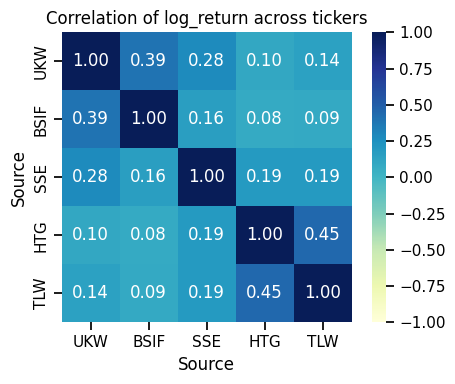

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tickers = ['UKW', 'BSIF', 'SSE', 'HTG', 'TLW']
val_col = "log_return"

df = df_theoretical.loc[:, ["Date", "Source", val_col]].copy()
df["Date"] = pd.to_datetime(df["Date"])

# long → wide (rows: dates, cols: tickers, values: log_return)
wide = (df[df["Source"].isin(tickers)]
          .pivot_table(index="Date", columns="Source", values=val_col, aggfunc="mean")
          .sort_index())

# keep only tickers that actually exist in the data
cols = [t for t in tickers if t in wide.columns]
corr = wide[cols].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="YlGnBu",
            square=True, cbar=True)
plt.title("Correlation of log_return across tickers")
plt.tight_layout()
plt.show()


## 5. Common Feature Panel and Feature Screening

This section constructs the shared feature panel used to prepare the retained model datasets. It preserves correlation, stationarity and XGBoost screening evidence but does not fit or evaluate an ARIMAX model.


### 5.1 Construct the Common Feature Panel


In [29]:

# --- 1) df_ftse: FTSE log-returns -> wide with Date as index ---
ftse_tickers   = ['FTSE', 'FTAS', 'FTMC']     # exact 'Source' names in df_fix_full
target_tickers = ['UKW', 'BSIF', 'SSE', 'HTG', 'TLW']  # optional, not used below

df0 = df_fix_full.copy()

# Ensure Date is a column and clean
if 'Date' not in df0.columns:
    df0 = df0.reset_index()
df0['Date'] = pd.to_datetime(df0['Date'], errors='coerce')
if pd.api.types.is_datetime64tz_dtype(df0['Date']):
    df0['Date'] = df0['Date'].dt.tz_convert(None)
df0['Date'] = df0['Date'].dt.normalize()
df0['Source'] = df0['Source'].astype(str).str.strip()

# Pivot FTSE to wide
ftse_pivot = (
    df0.loc[df0['Source'].isin(ftse_tickers), ['Date', 'Source', 'log_return']]
       .pivot_table(index='Date', columns='Source', values='log_return', aggfunc='last')
       .rename(columns={t: f'{t}_lr' for t in ftse_tickers})
)

# Ensure all three *_lr columns exist (even if some FTSE series are missing)
for t in ftse_tickers:
    col = f'{t}_lr'
    if col not in ftse_pivot.columns:
        ftse_pivot[col] = np.nan

df_ftse = ftse_pivot[[f'{t}_lr' for t in ftse_tickers]].sort_index()
df_ftse.index.name = 'Date'

# --- 2) df_0: copy of df_fix_full without FTSE rows, Date as index ---
df_0 = (
    df0.loc[~df0['Source'].isin(ftse_tickers)].copy()
       .set_index('Date')
       .sort_index()
)

# --- 3) df_model_features: merge by Date index ---
df_model_features = df_0.join(df_ftse, how='left')
df_model_features = df_model_features.drop(columns=['Close'], errors='ignore') 

#df_model_features.head(8)

### 5.2 Feature Correlation Screen


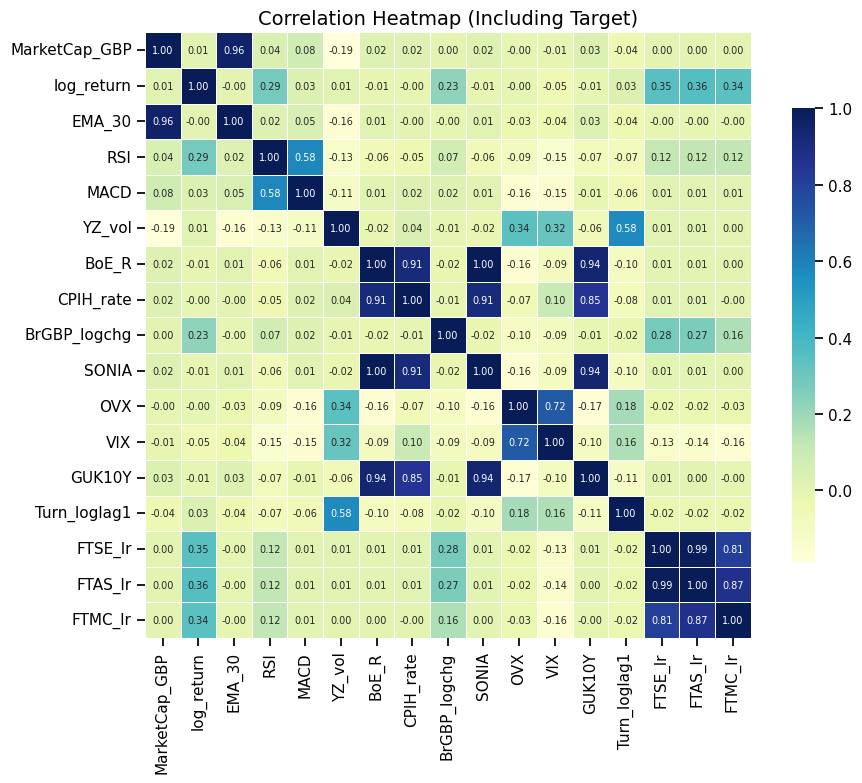

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# Include all exogenous features + target, exclude identifier
cols_for_corr = [col for col in df_model_features.columns if col != 'Source']

# Drop rows with any NaNs to compute correlation safely
df_corr = df_model_features[cols_for_corr].dropna()

# Compute correlation matrix
corr_matrix = df_corr.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    cmap="YlGnBu",
    annot=True,
    fmt=".2f",
    square=True,
    cbar_kws={"shrink": 0.75},
    linewidths=0.5,
    annot_kws={"size": 7}
)
plt.title("Correlation Heatmap (Including Target)", fontsize=14)
plt.tight_layout()
plt.show()


In [31]:
# reduce the noise after heathmap and XGB initial test
df_screened_features = df_model_features.drop(columns=["BoE_R", "SONIA", "CPIH_rate", "FTMC_lr", "FTAS_lr", "Turn_loglag1"])

### 5.3 Stationarity Checks


#### 5.3.1 Return and Price-Level ADF/KPSS Tests


In [32]:
# used to produce the report, saved in Charts

from statsmodels.tsa.stattools import adfuller, kpss

def generate_adf_report(df_theoretical, output_file=EDA_OUTPUT_DIR / "stationarity_report.csv"):
    tickers = df_theoretical['Source'].unique()
    report_lines = [
        "## Stationarity Check: ADF Test on Log Returns vs Price Levels\n",
        "*Lag selection: autolag='AIC' (Akaike Information Criterion).*\n",
        "| Ticker | Series      | ADF Statistic | p-value     | #Lags Used | #Observations | Stationary? | Notes |",
        "|--------|-------------|----------------|-------------|-------------|----------------|-------------|-------|"
    ]

    print("\nADF Test Results on Log Returns and Price Levels (autolag=AIC):\n")
    print("| Ticker | Series      | ADF Statistic | p-value     | #Lags Used | #Observations | Stationary? | Notes |")
    print("|--------|-------------|----------------|-------------|-------------|----------------|-------------|-------|")

    for ticker in tickers:
        df_ticker = df_theoretical[df_theoretical['Source'] == ticker]

        for series_name in ['log_return', 'Close']:
            if series_name not in df_ticker.columns:
                continue  # skip if missing
            series_data = df_ticker[series_name].dropna()
            if len(series_data) < 10:
                continue  # too short

            stat, p, lags, nobs, *_ = adfuller(series_data, autolag='AIC')
            is_stationary = "Yes" if p < 0.05 else "No"
            note = "Reject H0 (unit root)" if p < 0.05 else "Fail to reject H0"
            line = f"| {ticker} | {series_name:<11} | {stat:.5f} | {p:.5f} | {lags} | {nobs} | {is_stationary} | {note} |"
            report_lines.append(line)
            print(line)

    with open(output_file, 'w', encoding='utf-8') as f:
        f.write("\n".join(report_lines))
    print(f"\nADF stationarity report saved to {output_file}")
    
    
generate_adf_report(df_theoretical)


ADF Test Results on Log Returns and Price Levels (autolag=AIC):

| Ticker | Series      | ADF Statistic | p-value     | #Lags Used | #Observations | Stationary? | Notes |
|--------|-------------|----------------|-------------|-------------|----------------|-------------|-------|
| BSIF | log_return  | -14.88626 | 0.00000 | 17 | 2616 | Yes | Reject H0 (unit root) |
| BSIF | Close       | -1.44947 | 0.55834 | 18 | 2615 | No | Fail to reject H0 |
| HTG | log_return  | -36.08284 | 0.00000 | 1 | 2632 | Yes | Reject H0 (unit root) |
| HTG | Close       | -1.89612 | 0.33389 | 2 | 2631 | No | Fail to reject H0 |
| SSE | log_return  | -19.87280 | 0.00000 | 7 | 2626 | Yes | Reject H0 (unit root) |
| SSE | Close       | -2.10572 | 0.24222 | 7 | 2626 | No | Fail to reject H0 |
| TLW | log_return  | -13.49505 | 0.00000 | 15 | 2618 | Yes | Reject H0 (unit root) |
| TLW | Close       | -2.41904 | 0.13643 | 2 | 2631 | No | Fail to reject H0 |
| UKW | log_return  | -14.44503 | 0.00000 | 17 | 2616 | Ye

In [33]:
# used to produce the report, saved in Charts
import warnings

# Suppress interpolation warnings
warnings.filterwarnings("ignore", category=UserWarning)

def append_kpss_report(df_theoretical, output_file=EDA_OUTPUT_DIR / "stationarity_report.csv"):
    tickers = df_theoretical['Source'].unique()
    kpss_lines = [
        "\n\n## KPSS Stationarity Test on Log Returns vs Price Levels\n",
        "*Bandwidth: automatic ('nlags=auto'), regression='c'*\n",
        "| Ticker | Series      | Statistic | p-value | #Lags Used | #Observations | Stationary? | Notes |",
        "|--------|-------------|-----------|---------|-------------|----------------|-------------|-------|"
    ]

    print("\nKPSS Test Results:\n")
    print("| Ticker | Series      | Statistic | p-value | #Lags Used | #Observations | Stationary? | Notes |")
    print("|--------|-------------|-----------|---------|-------------|----------------|-------------|-------|")

    for ticker in tickers:
        df_ticker = df_theoretical[df_theoretical['Source'] == ticker]

        for series_name in ['log_return', 'Close']:
            if series_name not in df_ticker.columns:
                continue
            series_data = df_ticker[series_name].dropna()
            if len(series_data) < 10:
                continue

            try:
                kpss_stat, kpss_p, kpss_lags, _ = kpss(series_data, regression='c', nlags='auto')
                if kpss_p < 0.01:
                    p_val_str = "<0.01"
                elif kpss_p < 0.05:
                    p_val_str = "<0.05"
                elif kpss_p < 0.1:
                    p_val_str = "~0.1"
                else:
                    p_val_str = ">0.1"

                kpss_stationary = "Yes" if kpss_p > 0.05 else "No"
                kpss_note = "Fail to reject H0 (stationary)" if kpss_p > 0.05 else "Reject H0 (non-stationary)"
                kpss_line = f"| {ticker} | {series_name:<11} | {kpss_stat:>9.5f} | {p_val_str:<7} | {kpss_lags:>11} | {len(series_data):>14} | {kpss_stationary:<11} | {kpss_note} |"
            except Exception as e:
                kpss_line = f"| {ticker} | {series_name:<11} |     ERROR   |   N/A   |     N/A     | {len(series_data):>14} |     N/A      | Error: {str(e)} |"
            kpss_lines.append(kpss_line)
            print(kpss_line)

    with open(output_file, 'a', encoding='utf-8') as f:
        f.write("\n".join(kpss_lines))
    
append_kpss_report(df_theoretical)


KPSS Test Results:

| Ticker | Series      | Statistic | p-value | #Lags Used | #Observations | Stationary? | Notes |
|--------|-------------|-----------|---------|-------------|----------------|-------------|-------|
| BSIF | log_return  |   0.15807 | >0.1    |           4 |           2634 | Yes         | Fail to reject H0 (stationary) |
| BSIF | Close       |   1.84421 | <0.05   |          30 |           2634 | No          | Reject H0 (non-stationary) |
| HTG | log_return  |   0.05496 | >0.1    |           7 |           2634 | Yes         | Fail to reject H0 (stationary) |
| HTG | Close       |   3.44589 | <0.05   |          30 |           2634 | No          | Reject H0 (non-stationary) |
| SSE | log_return  |   0.07803 | >0.1    |          12 |           2634 | Yes         | Fail to reject H0 (stationary) |
| SSE | Close       |   3.76770 | <0.05   |          30 |           2634 | No          | Reject H0 (non-stationary) |
| TLW | log_return  |   0.03050 | >0.1    |           2 |  

#### 5.3.2 Candidate-Feature Tests and Submitted Differencing


In [34]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss

# Assume df_screened_features is already loaded in the environment
# Select numeric features only (exclude non-numeric columns)
numeric_cols = df_screened_features.select_dtypes(include='number').columns
features = [col for col in numeric_cols if col != 'log_return']

# Function to apply ADF and KPSS tests
def stationarity_tests(series):
    series = series.dropna()
    try:
        adf_p = adfuller(series, autolag='AIC')[1]
    except Exception:
        adf_p = None
    try:
        kpss_p = kpss(series, nlags="auto")[1]
    except Exception:
        kpss_p = None
    return pd.Series({'ADF_pval': adf_p, 'KPSS_pval': kpss_p})

# Run tests for all features
stationarity_results = pd.DataFrame({col: stationarity_tests(df_screened_features[col]) for col in features}).T

# Interpret results
def interpret_row(row):
    if row['ADF_pval'] is None or row['KPSS_pval'] is None:
        return "Error"
    if row['ADF_pval'] < 0.05 and row['KPSS_pval'] > 0.05:
        return "Stationary"
    else:
        return "Non-stationary"

stationarity_results["Interpretation"] = stationarity_results.apply(interpret_row, axis=1)

stationarity_results



,ADF_pval,KPSS_pval,Interpretation
MarketCap_GBP,5.144536e-02,0.010000,Non-stationary
EMA_30,8.488687e-03,0.010000,Non-stationary
RSI,1.002793e-14,0.100000,Stationary
MACD,7.248014e-14,0.100000,Stationary
YZ_vol,1.336380e-05,0.010000,Non-stationary
BrGBP_logchg,1.459856e-28,0.100000,Stationary
OVX,1.052035e-05,0.051891,Stationary
VIX,5.046289e-06,0.010000,Non-stationary
GUK10Y,9.461302e-01,0.010000,Non-stationary
FTSE_lr,8.402052e-30,0.100000,Stationary


In [35]:


# Copy original cropped dataframe
df_stationarity_adjusted = df_screened_features.copy()

# List of features to difference
features_to_diff = ["EMA_30", "YZ_vol", "GUK10Y", "VIX", "MarketCap_GBP"]

# Apply differencing and rename columns
for col in features_to_diff:
    df_stationarity_adjusted[f"{col}_diff"] = df_stationarity_adjusted[col].diff()

# Drop original non-stationary columns
df_stationarity_adjusted.drop(columns=features_to_diff, inplace=True)

# Drop initial NaNs caused by differencing
df_stationarity_adjusted.dropna(inplace=True)

print(df_stationarity_adjusted.head())

           Source  log_return        RSI       MACD  BrGBP_logchg    OVX  \
Date                                                                       
2015-02-12    HTG    0.053283  54.847583   5.497023      0.043809  58.69   
2015-02-12    SSE   -0.002497  54.763586  14.632303      0.043809  58.69   
2015-02-12    TLW    0.001299  47.475733   2.471862      0.043809  58.69   
2015-02-12    UKW   -0.021316  30.057902  -1.318841      0.043809  58.69   
2015-02-13   BSIF    0.007398  48.830980  -0.428106      0.068428  55.53   

             FTSE_lr  EMA_30_diff  YZ_vol_diff  GUK10Y_diff  VIX_diff  \
Date                                                                    
2015-02-12  0.001451   374.377595     0.036974        0.000      0.00   
2015-02-12  0.001451  1099.263980    -0.033004        0.000      0.00   
2015-02-12  0.001451 -1240.522996     0.014901        0.000      0.00   
2015-02-12  0.001451  -227.751931    -0.017269        0.000      0.00   
2015-02-13  0.006627    -5.38

### 5.4 XGBoost Feature-Importance Probe


In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor

# ---------------- Config ----------------
train_ratio   = 0.70
val_ratio     = 0.15
purge_steps   = 5
exog_lag      = 1
top_k         = 12

xgb_params = dict(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.0,
    objective="reg:squarederror",
    random_state=7,
    n_jobs=-1,
    tree_method="hist",
)
early_stop_rounds = 100

# ---------------- Outputs ----------------
imp_overall_file = EDA_OUTPUT_DIR / "xgb_feature_importance_overall.csv"
xgb_metrics_file = EDA_OUTPUT_DIR / "xgb_probe_metrics.csv"

# ---------------- Prep data ----------------
if "df_model_features" not in globals():
    raise RuntimeError("df_model_features is not defined.")
if "target_tickers" not in globals():
    raise RuntimeError("target_tickers is not defined.")

df = df_screened_features.copy()
if "Date" in df.columns:
    df = df.set_index("Date")
df.index = pd.to_datetime(df.index)
df = df.sort_index()

all_exog = [c for c in df.columns if c not in ["Source", "log_return"]]
if not all_exog:
    raise RuntimeError("No exogenous columns found in df_model_features.")

if exog_lag and exog_lag > 0:
    df[all_exog] = df.groupby("Source", group_keys=False)[all_exog].shift(exog_lag)

def split_with_purge_idx(d: pd.DataFrame, purge_steps: int):
    n = len(d)
    i_train_end = int(n * train_ratio) - 1
    i_val_end   = int(n * (train_ratio + val_ratio)) - 1
    i_val_start  = min(n, i_train_end + 1 + purge_steps)
    i_test_start = min(n, max(i_val_end + 1 + purge_steps, i_val_start))
    d_train = d.iloc[:i_train_end + 1]
    d_val   = d.iloc[i_val_start : i_val_end + 1] if i_val_start <= i_val_end else d.iloc[0:0]
    d_test  = d.iloc[i_test_start:]
    return d_train, d_val, d_test

def _norm(v):
    v = np.asarray(v, dtype=float)
    s = v.sum()
    return (v / s) if s > 0 else np.zeros_like(v)

def _get_importance_array(booster, feat_names, kind):
    score = booster.get_score(importance_type=kind)
    uses_index_keys = all(k.startswith("f") and k[1:].isdigit() for k in score.keys()) if score else False
    return np.array([
        float(score.get(f"f{i}", 0.0) if uses_index_keys else score.get(name, 0.0))
        for i, name in enumerate(feat_names)
    ], dtype=float)

def fit_xgb_earlystop(model, Xtr, ytr, Xva, yva):
    if Xva is None or len(Xva) == 0:
        model.fit(Xtr, ytr)
        return model
    try:
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)],
                  early_stopping_rounds=early_stop_rounds, verbose=False)
        return model
    except TypeError:
        model.fit(Xtr, ytr, eval_set=[(Xva, yva)])
        return model

imp_rows = []
metric_rows = []

for tic in target_tickers:
    d = df[df["Source"] == tic].copy()
    if d.empty:
        continue

    d = d.dropna(subset=["log_return"] + all_exog).sort_index()
    if len(d) < 300:
        continue

    d_tr, d_va, d_te = split_with_purge_idx(d, purge_steps)
    if len(d_va) == 0:
        cut = int(len(d_tr) * 0.85)
        d_va = d_tr.iloc[cut:].copy()
        d_tr = d_tr.iloc[:cut].copy()
        if len(d_va) == 0:
            continue

    feat_names = list(all_exog)
    Xtr, ytr = d_tr[feat_names], d_tr["log_return"]
    Xva, yva = d_va[feat_names], d_va["log_return"]
    Xte, yte = d_te[feat_names], d_te["log_return"]

    model = XGBRegressor(**xgb_params, eval_metric="rmse")
    model = fit_xgb_earlystop(model, Xtr, ytr, Xva, yva)

    if len(Xte):
        yhat = model.predict(Xte)
        metric_rows.append({
            "Ticker": tic,
            "MAE": mean_absolute_error(yte, yhat),
            "RMSE": np.sqrt(mean_squared_error(yte, yhat)),
            "R²": r2_score(yte, yhat) if np.var(yte) > 0 else np.nan,
            "SignAcc": (np.sign(yte) == np.sign(yhat)).mean(),
            "BearMiss": ((yte < 0) & (yhat >= 0)).sum() / max(1, (yte < 0).sum())
        })

    booster = model.get_booster()
    gain   = _get_importance_array(booster, feat_names, "gain")
    weight = _get_importance_array(booster, feat_names, "weight")
    cover  = _get_importance_array(booster, feat_names, "cover")

    gain_n, weight_n, cover_n = _norm(gain), _norm(weight), _norm(cover)

    try:
        pi = permutation_importance(
            model, Xva, yva,
            n_repeats=10, random_state=7,
            scoring="neg_mean_squared_error"
        )
        perm_n = _norm(np.maximum(0, pi.importances_mean))
    except Exception:
        perm_n = np.zeros(len(feat_names))

    avg = np.vstack([gain_n, weight_n, cover_n, perm_n]).mean(axis=0)

    for i, f in enumerate(feat_names):
        imp_rows.append({"Feature": f, "AvgScore": float(avg[i])})

# ---------------- Aggregate ----------------
if not imp_rows:
    raise RuntimeError("No feature rows produced (check NaNs / lengths).")

agg = (pd.DataFrame(imp_rows)
       .groupby("Feature", as_index=False)["AvgScore"]
       .mean()
       .sort_values("AvgScore", ascending=False)
       .reset_index(drop=True))
agg["Rank"] = np.arange(1, len(agg) + 1)

agg.to_csv(imp_overall_file, index=False)

print("Top features with overall AvgScore:")
print(agg.head(top_k).to_string(index=False))

if metric_rows:
    pd.DataFrame(metric_rows).to_csv(xgb_metrics_file, index=False)



[0]	validation_0-rmse:0.01312
[1]	validation_0-rmse:0.01309
[2]	validation_0-rmse:0.01310
[3]	validation_0-rmse:0.01309
[4]	validation_0-rmse:0.01309
[5]	validation_0-rmse:0.01309
[6]	validation_0-rmse:0.01309
[7]	validation_0-rmse:0.01309
[8]	validation_0-rmse:0.01310
[9]	validation_0-rmse:0.01309
[10]	validation_0-rmse:0.01309
[11]	validation_0-rmse:0.01311
[12]	validation_0-rmse:0.01312
[13]	validation_0-rmse:0.01322
[14]	validation_0-rmse:0.01319
[15]	validation_0-rmse:0.01319
[16]	validation_0-rmse:0.01322
[17]	validation_0-rmse:0.01321
[18]	validation_0-rmse:0.01322
[19]	validation_0-rmse:0.01323
[20]	validation_0-rmse:0.01322
[21]	validation_0-rmse:0.01322
[22]	validation_0-rmse:0.01323
[23]	validation_0-rmse:0.01322
[24]	validation_0-rmse:0.01323
[25]	validation_0-rmse:0.01331
[26]	validation_0-rmse:0.01335
[27]	validation_0-rmse:0.01334
[28]	validation_0-rmse:0.01335
[29]	validation_0-rmse:0.01335
[30]	validation_0-rmse:0.01334
[31]	validation_0-rmse:0.01334
[32]	validation_0-

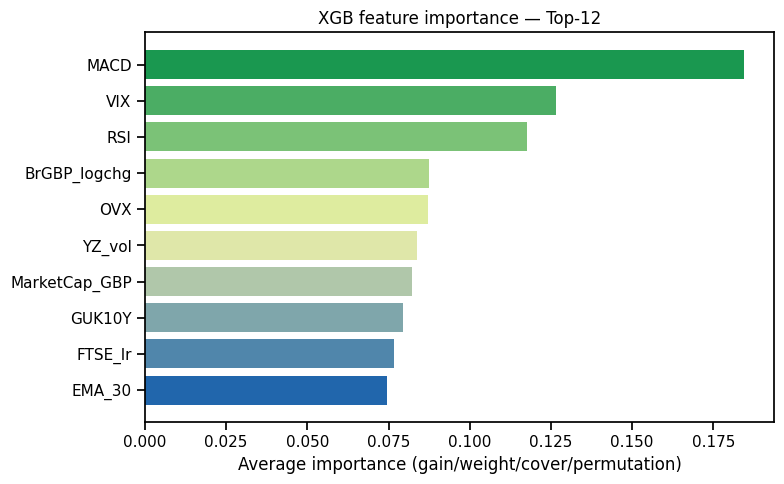

In [37]:
# === Plot feature importance (old method) — BYG colors, horizontal bar ===
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# use existing `agg` if present; otherwise load from CSV you just saved
try:
    _ = agg
except NameError:
    agg = pd.read_csv(imp_overall_file)

topK = agg.sort_values("AvgScore", ascending=False).head(top_k).iloc[::-1]

BYG = sns.blend_palette(["#2166ac", "#f7f7a9", "#1a9850"], as_cmap=False, n_colors=len(topK))

plt.figure(figsize=(8, max(5, 0.35*len(topK))))
plt.barh(topK["Feature"], topK["AvgScore"], color=BYG)
plt.xlabel("Average importance (gain/weight/cover/permutation)")
plt.title("XGB feature importance — Top-12")
plt.tight_layout()
plt.savefig(EDA_OUTPUT_DIR / "xgb_feature_importance_BYG.png", dpi=160)
plt.show()


## 6. Fixed Modelling Datasets

This section applies the submitted fixed train/purge/test split, confirms period flags and dimensions, encodes tickers, and writes the frozen inputs used by the retained result paths.


### 6.1 Fixed Train/Purge/Test Split


In [38]:

# 1. Define cutoff and purge
cutoff_date = pd.to_datetime("2024-04-22")
purge_days = 8

# 2. Ensure correct sorting
df_model_features = df_model_features.sort_index().copy()

# 3. Drop globally unused columns 
# !!! DECIDED NOT TO USE PCA for FTSEs because could not find a simple method 
# to do it without leakage in cross-validation settings. 
# left the most significant, dropped other to avoid multicollinearity
df_model_features.drop(columns=["CPIH_rate", "BoE_R", "SONIA","FTAS_lr", "FTSE_lr"], inplace=True) 

# 4. Add binary period flags
df_model_features = add_dissertation_period_flags(df_model_features)

# 5. Split into fit/test sets and retain purge rows as forecast context only
df_train, df_test, purge_date = fixed_dissertation_split(
    df_model_features, cutoff_date=cutoff_date, purge_days=purge_days
)
df_context = df_model_features.loc[
    (df_model_features.index >= purge_date)
    & (df_model_features.index < cutoff_date)
].copy()




### 6.2 Validate Period Flags and Split Dimensions


In [39]:
# Period flags only (no scaling, no saving) 

flags = ["brexit_transition", "covid_awareness", "post_pandemic", "war_ukraine"]

def ensure_flags(df: pd.DataFrame) -> pd.DataFrame:
    # make sure Date exists as a datetime Series (works whether it's a column or index)
    if "Date" in df.columns:
        _dates = pd.to_datetime(df["Date"])
    else:
        df = df.copy()
        df.index = pd.to_datetime(df.index)
        _dates = df.index

    # create missing flag columns as 0; keep existing values if already present
    for col in flags:
        if col not in df.columns:
            df[col] = 0

    # (optional) if you compute flags by date elsewhere, do it there; we only enforce dtype here
    df[flags] = df[flags].astype("int8")
    return df

df_train = ensure_flags(df_train)
df_context = ensure_flags(df_context)
df_test  = ensure_flags(df_test)

In [40]:
print(df_train.shape)
print(df_test.shape)
print(df_train.head())

(11570, 17)
(1575, 17)
           Source  MarketCap_GBP  log_return       EMA_30        RSI  \
Date                                                                   
2015-02-12   BSIF   1.434828e+08    0.000000   100.998131  41.101789   
2015-02-12    HTG   7.487405e+08    0.053283   475.375726  54.847583   
2015-02-12    SSE   2.042703e+10   -0.002497  1574.639706  54.763586   
2015-02-12    TLW   3.496682e+09    0.001299   334.116710  47.475733   
2015-02-12    UKW   4.733818e+08   -0.021316   106.364779  30.057902   

                 MACD    YZ_vol  BrGBP_logchg    OVX    VIX  GUK10Y  \
Date                                                                  
2015-02-12  -0.496257  0.006032      0.043809  58.69  15.34   1.666   
2015-02-12   5.497023  0.043006      0.043809  58.69  15.34   1.666   
2015-02-12  14.632303  0.010002      0.043809  58.69  15.34   1.666   
2015-02-12   2.471862  0.024903      0.043809  58.69  15.34   1.666   
2015-02-12  -1.318841  0.007634      0.043809 

### 6.3 Encode Tickers and Save Retained Model Inputs


In [41]:
# --- Ticker encoding for embeddings + save reproducibles (NO SCALING/PCA) ---
import os, json

DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Stable mapping (for reproducible embeddings)
ticker_to_id = {"BSIF": 0, "HTG": 1, "SSE": 2, "TLW": 3, "UKW": 4}

# Ensure required columns exist
assert all("Source" in frame.columns for frame in [df_train, df_context, df_test]), "Missing 'Source' column."
assert all("log_return" in frame.columns for frame in [df_train, df_context, df_test]), "Missing target 'log_return'."

# Add ticker_id
df_train = df_train.copy()
df_context = df_context.copy()
df_test  = df_test.copy()
df_train["ticker_id"] = df_train["Source"].map(ticker_to_id).astype("int8")
df_context["ticker_id"] = df_context["Source"].map(ticker_to_id).astype("int8")
df_test["ticker_id"]  = df_test["Source"].map(ticker_to_id).astype("int8")

# Drop human-readable ticker for model input 
df_LSTM_train = df_train.drop(columns=["Source"])
df_LSTM_context = df_context.drop(columns=["Source"])
df_LSTM_test  = df_test.drop(columns=["Source"])

# Ensure Date is a column (not index) before saving
if "Date" not in df_LSTM_train.columns:
    df_LSTM_train = df_LSTM_train.reset_index()
if "Date" not in df_LSTM_context.columns:
    df_LSTM_context = df_LSTM_context.reset_index()
if "Date" not in df_LSTM_test.columns:
    df_LSTM_test = df_LSTM_test.reset_index()

# Save datasets for LSTM / reuse
df_LSTM_train.to_csv(DATA_OUTPUT_DIR / "df_LSTM_train.csv", index=False)
df_LSTM_context.to_csv(DATA_OUTPUT_DIR / "df_LSTM_context.csv", index=False)
df_LSTM_test.to_csv(DATA_OUTPUT_DIR / "df_LSTM_test.csv", index=False)

# Flags + manifest (no scaling)
flags = ["brexit_transition", "covid_awareness", "post_pandemic", "war_ukraine"]
numeric_cols = [
    "EMA_30","RSI","MACD","YZ_vol","BrGBP_logchg",
    "MarketCap_GBP","OVX","GUK10Y","FTSE_lr"
]
numeric_cols = [c for c in numeric_cols if c in df_LSTM_train.columns]  # safety

with open(DATA_OUTPUT_DIR / "periods_and_ticker_mapping.md", "w", encoding="utf-8") as f:
    f.write("# Codebook: Period Flags & Ticker Mapping\n\n")
    f.write("## Ticker → ID (for embeddings)\n")
    for k, v in ticker_to_id.items():
        f.write(f"- `{k}` → `{v}`\n")
    f.write("\n## Period Flags (binary)\n")
    f.write("- `brexit_transition`: 2016-06-23 → 2020-01-19\n")
    f.write("- `covid_awareness`: 2020-01-20 → 2020-11-30\n")
    f.write("- `post_pandemic`: 2020-12-01 → 2022-02-23\n")
    f.write("- `war_ukraine`: 2022-02-24 → end of dataset\n")
    f.write("\n## Split & Purge\n")
    f.write("- Train: up to 2024-04-13\n")
    f.write("- Purge window excluded from fitting and scoring, retained as forecast context: 2024-04-14 → 2024-04-21 (8 calendar days)\n")
    f.write("- Test: from 2024-04-22 onward\n")
    f.write("\n## Scaling / PCA\n")
    f.write("- None. Numeric features kept in original scale; flags & ticker_id as is.\n")

manifest = {
    "ticker_to_id": ticker_to_id,
    "numeric_cols": numeric_cols,
    "flags": flags,
    "target": "log_return",
    "train_end": "2024-04-13",
    "purge_window": ["2024-04-14", "2024-04-21"],
    "purge_usage": "forecast_context_only",
    "test_start": "2024-04-22"
}
with open(DATA_OUTPUT_DIR / "manifest_LSTM.json", "w", encoding="utf-8") as jf:
    json.dump(manifest, jf, indent=2)

print(f"Saved modelling datasets and metadata under {DATA_OUTPUT_DIR.resolve()}.")


Saved modelling datasets and metadata under <PROJECT_ROOT>\outputs\data.
